<a href="https://colab.research.google.com/github/253220100-hue/Red-Wine-Quality/blob/main/Sesion7_Actividad4_Schedulers_Independiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 7 · Actividad 4
# Distintos caminos desde el ruido: comparación de schedulers

**Curso:** Introducción a la Inteligencia Artificial Generativa  
**Modalidad:** laboratorio guiado en Google Colab

---

## Propósito

En esta actividad compararás distintos **schedulers** para descubrir cómo cambia una imagen cuando el modelo utiliza diferentes estrategias durante el proceso inverso de difusión.

Analizaremos:

- coherencia visual;
- nivel de detalle;
- estilo percibido;
- estabilidad del resultado;
- tiempo de generación.

> **Regla experimental:** cambiaremos únicamente el scheduler.  
> El modelo, el prompt, la semilla, el número de pasos, el Guidance Scale y el tamaño permanecerán constantes.


La idea central es:

> **El modelo puede ser el mismo, pero la estrategia de eliminación de ruido puede modificar el resultado.**

### Preguntas iniciales

- ¿Todos los caminos desde el ruido producirán la misma imagen?
- ¿Existe un scheduler universalmente mejor?
- ¿El scheduler más rápido será también el de mayor calidad?



# 0. Preparación del entorno

En Google Colab selecciona:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después ejecuta las celdas en orden.

Este cuaderno es completamente independiente y no requiere ejecutar ninguna actividad anterior.


In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No se detectó una GPU. Selecciona: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )


Versión de PyTorch: 2.11.0+cu128
GPU disponible: True
GPU detectada: Tesla T4


# 1. Configuración del guardado

Puedes guardar los resultados:

- temporalmente en Colab;
- permanentemente en Google Drive.

Para guardar en Drive cambia `USAR_DRIVE` a `True`.


In [2]:
from pathlib import Path

USAR_DRIVE = False

if USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CARPETA_RESULTADOS = Path(
        "/content/drive/MyDrive/IA_Generativa/Sesion7/Actividad4_Schedulers"
    )
else:
    CARPETA_RESULTADOS = Path("/content/Actividad4_Schedulers")

CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Los resultados se guardarán en:", CARPETA_RESULTADOS)


Los resultados se guardarán en: /content/Actividad4_Schedulers


# 2. Instalación de bibliotecas

In [3]:
!pip -q install -U diffusers transformers accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 60.8 MB/s eta 0:00:00


# 3. Carga del modelo

Usaremos Stable Diffusion 1.5 y compararemos cinco schedulers:

- DDIM;
- Euler;
- Euler ancestral;
- Heun;
- DPM-Solver++.

> **Nota:** el scheduler no cambia lo aprendido por el modelo. Cambia la estrategia utilizada para avanzar desde el ruido hacia la imagen.


In [4]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from diffusers import (
    StableDiffusionPipeline,
    DDIMScheduler,
    EulerDiscreteScheduler,
    EulerAncestralDiscreteScheduler,
    HeunDiscreteScheduler,
    DPMSolverMultistepScheduler
)

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None
)

pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

CONFIG_BASE = pipe.scheduler.config

print("Modelo cargado correctamente.")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado correctamente.


# 4. Diseño del experimento

Mantendremos constantes:

- **Prompt:** un dragón volando sobre Tokio;
- **Semilla:** 42;
- **Pasos:** 25;
- **Guidance Scale:** 7.5;
- **Tamaño:** 512 × 512 píxeles.

Solo cambiaremos el scheduler.


In [5]:
PROMPT = "A dragon flying over Tokyo at night, cinematic lighting, highly detailed"

SEED = 42
STEPS = 25
GUIDANCE = 7.5
WIDTH = 512
HEIGHT = 512

SCHEDULERS = {
    "DDIM": DDIMScheduler.from_config(CONFIG_BASE),
    "Euler": EulerDiscreteScheduler.from_config(CONFIG_BASE),
    "Euler ancestral": EulerAncestralDiscreteScheduler.from_config(CONFIG_BASE),
    "Heun": HeunDiscreteScheduler.from_config(CONFIG_BASE),
    "DPM-Solver++": DPMSolverMultistepScheduler.from_config(
        CONFIG_BASE,
        algorithm_type="dpmsolver++"
    )
}

def generar_con_scheduler(nombre, scheduler):
    pipe.scheduler = scheduler
    generator = torch.Generator(device="cuda").manual_seed(SEED)

    inicio = time.time()

    imagen = pipe(
        prompt=PROMPT,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    duracion = time.time() - inicio

    nombre_archivo = (
        nombre.lower()
        .replace(" ", "_")
        .replace("+", "plus")
    )

    imagen.save(CARPETA_RESULTADOS / f"{nombre_archivo}.png")
    return imagen, duracion


# 5. Predicción

Antes de ejecutar responde:

1. ¿Cuál scheduler crees que producirá mayor detalle?
2. ¿Cuál podría generar una imagen más artística?
3. ¿Cuál imaginas que será más rápido?
4. ¿Crees que las cinco imágenes serán claramente diferentes?


# 6. Generación de imágenes

Se generará una imagen por scheduler usando exactamente el mismo prompt, semilla y parámetros.

> **Observar:**
> - forma del dragón;
> - composición urbana;
> - iluminación;
> - nitidez;
> - coherencia;
> - artefactos.


In [6]:
imagenes = []
tiempos = []
nombres = []

for nombre, scheduler in SCHEDULERS.items():
    print(f"Generando con {nombre}...")
    imagen, duracion = generar_con_scheduler(nombre, scheduler)
    nombres.append(nombre)
    imagenes.append(imagen)
    tiempos.append(duracion)

print("Generación terminada.")


Generando con DDIM...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con Euler...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con Euler ancestral...


...

Generando con Heun...


  0%|          | 0/25 [00:00<?, ?it/s]

Generando con DPM-Solver++...


  0%|          | 0/25 [00:00<?, ?it/s]

Generación terminada.


# 7. Comparación visual

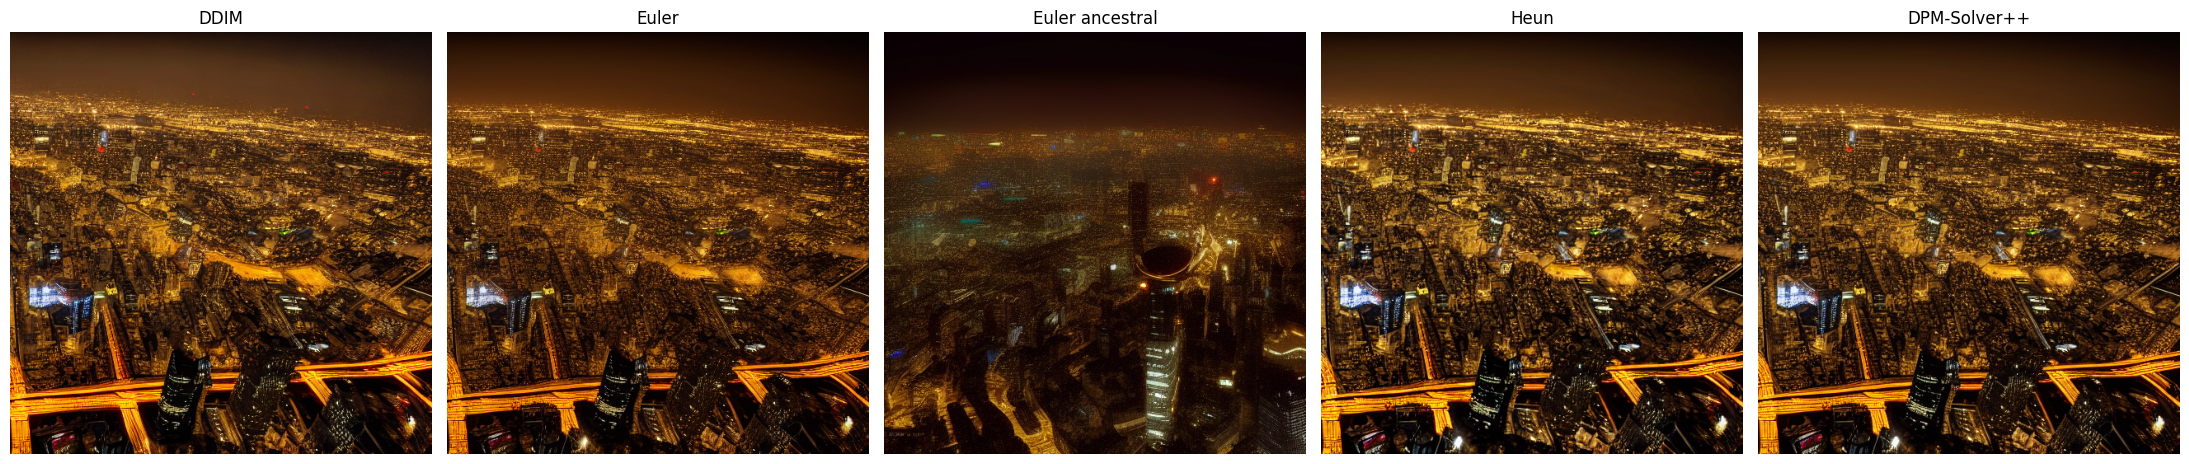

Comparación guardada en: /content/Actividad4_Schedulers/comparacion_schedulers.png


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, imagen, nombre in zip(axes, imagenes, nombres):
    ax.imshow(imagen)
    ax.set_title(nombre)
    ax.axis("off")

plt.tight_layout()

ruta_comparacion = CARPETA_RESULTADOS / "comparacion_schedulers.png"
plt.savefig(ruta_comparacion, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:", ruta_comparacion)


# 8. Comparación de tiempos

In [8]:
tabla_tiempos = pd.DataFrame({
    "Scheduler": nombres,
    "Tiempo de generación (s)": [round(t, 2) for t in tiempos]
}).sort_values("Tiempo de generación (s)")

tabla_tiempos


,Scheduler,Tiempo de generación (s)
4,DPM-Solver++,6.21
2,Euler ancestral,7.60
1,Euler,8.44
0,DDIM,11.93
3,Heun,12.62


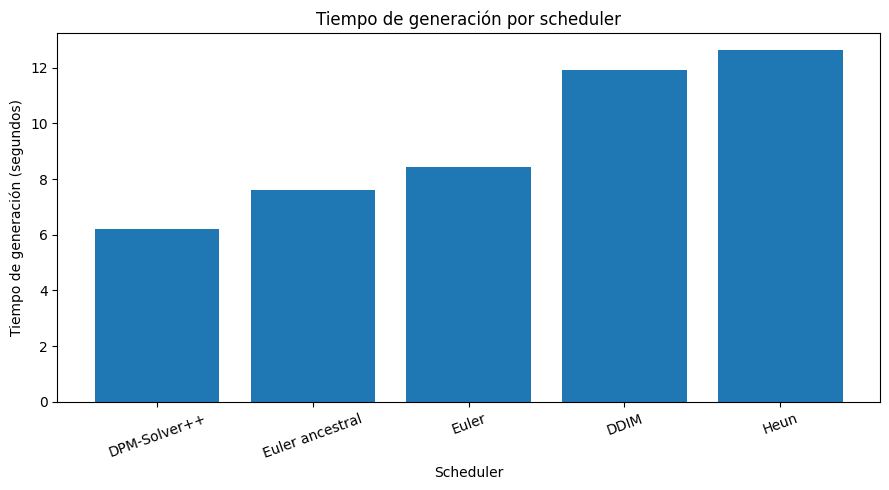

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(tabla_tiempos["Scheduler"], tabla_tiempos["Tiempo de generación (s)"])
plt.xlabel("Scheduler")
plt.ylabel("Tiempo de generación (segundos)")
plt.title("Tiempo de generación por scheduler")
plt.xticks(rotation=20)
plt.tight_layout()

ruta_grafica = CARPETA_RESULTADOS / "tiempo_por_scheduler.png"
plt.savefig(ruta_grafica, dpi=150, bbox_inches="tight")
plt.show()


# 9. Registro de observaciones

Evalúa cada resultado en una escala de 1 a 5.

| Scheduler | Coherencia | Detalle | Realismo | Estilo artístico | Artefactos | Observaciones |
|---|---:|---:|---:|---:|---:|---|
| DDIM | | | | | | |
| Euler | | | | | | |
| Euler ancestral | | | | | | |
| Heun | | | | | | |
| DPM-Solver++ | | | | | | |


# 10. Preguntas de análisis

### 1.
¿Qué scheduler produjo la imagen más coherente?

### 2.
¿Cuál produjo mayor detalle?

### 3.
¿Cuál generó una apariencia más artística o impredecible?

### 4.
¿Cuál fue el más rápido?

### 5.
¿El más rápido fue también el mejor visualmente?

### 6.
¿Las diferencias fueron grandes o sutiles?

### 7.
¿Existe un scheduler que puedas declarar “mejor” en todos los casos?

### 8.
Formula una conclusión:

> El scheduler influye en la generación porque...


> **Reflexión:**  
> “El scheduler es la estrategia de navegación. El modelo conoce el destino probable, pero diferentes rutas pueden producir resultados distintos.”


# 11. Mini reto: elige el scheduler adecuado

Selecciona uno de estos objetivos:

- mayor rapidez;
- mayor realismo;
- mayor detalle;
- apariencia más artística.

Elige un scheduler con base en tus resultados y genera una imagen nueva usando el siguiente prompt:

> `A futuristic motorcycle racing through a neon city at night`

Mantén constantes los demás parámetros.


  0%|          | 0/25 [00:00<?, ?it/s]

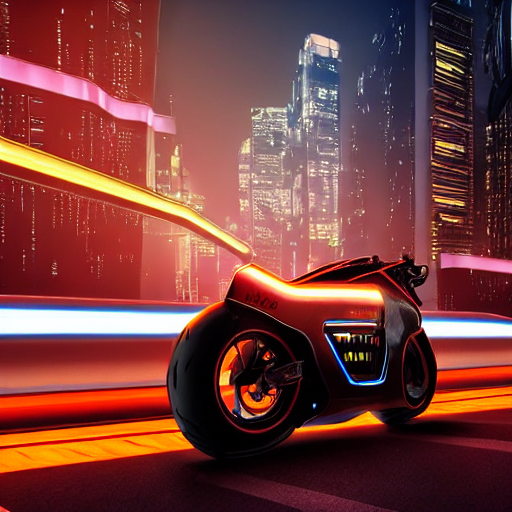

Scheduler elegido: Heun
Tiempo: 10.74 segundos


In [13]:
PROMPT_RETO = "A futuristic motorcycle racing through a neon city at night"

# Escribe exactamente uno de estos nombres:
# "DDIM", "Euler", "Euler ancestral", "Heun", "DPM-Solver++"
SCHEDULER_ELEGIDO = "Heun"

pipe.scheduler = SCHEDULERS[SCHEDULER_ELEGIDO]
generator = torch.Generator(device="cuda").manual_seed(SEED)

inicio = time.time()

imagen_reto = pipe(
    prompt=PROMPT_RETO,
    num_inference_steps=STEPS,
    guidance_scale=GUIDANCE,
    width=WIDTH,
    height=HEIGHT,
    generator=generator
).images[0]

tiempo_reto = time.time() - inicio

ruta_reto = CARPETA_RESULTADOS / "mini_reto_scheduler.png"
imagen_reto.save(ruta_reto)

display(imagen_reto)
print("Scheduler elegido:", SCHEDULER_ELEGIDO)
print(f"Tiempo: {tiempo_reto:.2f} segundos")


## Reflexión del mini reto

- Objetivo seleccionado:
- Scheduler elegido:
- Evidencia que justificó la elección:
- Resultado obtenido:
- ¿El scheduler respondió como esperabas?
- ¿Probarías otro? ¿Cuál?


# 12. Evidencia de aprendizaje

Entrega:

1. comparación de los cinco schedulers;
2. tabla de observaciones;
3. tabla y gráfica de tiempos;
4. respuestas de análisis;
5. imagen del mini reto;
6. conclusión personal de máximo 100 palabras.


# 13. Cierre conceptual

Un scheduler determina cómo se actualiza la imagen durante cada paso de eliminación de ruido.

La idea principal es:

- el modelo permanece igual;
- el ruido inicial permanece igual;
- el prompt permanece igual;
- la estrategia de muestreo cambia;
- el resultado puede cambiar.

> **No existe un scheduler universalmente mejor: existe uno más adecuado para cada objetivo.**
